In [1]:
import os

project_path = os.getcwd()

print("Notebook is working.")
print("Current path:", project_path)

Notebook is working.
Current path: C:\Users\user\Desktop\Plant_Stress_Domain_Shift\notebooks


In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Project root:", os.getcwd())

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift


In [3]:
import os

folders = ["data", "notebooks", "src", "results", "models"]

for folder in folders:
    print(folder, "exists:", os.path.exists(folder))

data exists: True
notebooks exists: True
src exists: True
results exists: True
models exists: True


In [4]:
import os

dataset_folders = [
    "data/PlantVillage",
    "data/PlantDoc",
    "data/PlantPathology2020"
]

for folder in dataset_folders:
    print(folder, "exists:", os.path.exists(folder))

data/PlantVillage exists: True
data/PlantDoc exists: True
data/PlantPathology2020 exists: True


In [6]:
!pip install datasets

In [7]:
from datasets import load_dataset

plantvillage = load_dataset("mohanty/PlantVillage", "color")

print(plantvillage)

README.md: 0.00B [00:00, ?B/s]

C:\Users\user\Desktop\Plant_Stress_Domain_Shift\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\datasets--mohanty--PlantVillage. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ValueError: BuilderConfig 'color' not found. Available: ['default']

In [8]:
from datasets import load_dataset

plantvillage = load_dataset("mohanty/PlantVillage")

print(plantvillage)

ValueError: BuilderConfig 'color' not found. Available: ['default']

In [9]:
from datasets import load_dataset

plantvillage = load_dataset("mohanty/PlantVillage", "default")

print(plantvillage)

color_train.txt: 0.00B [00:00, ?B/s]

grayscale_train.txt: 0.00B [00:00, ?B/s]

segmented_train.txt: 0.00B [00:00, ?B/s]

color_test.txt: 0.00B [00:00, ?B/s]

grayscale_test.txt: 0.00B [00:00, ?B/s]

segmented_test.txt: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})


In [10]:
plantvillage["train"][0]

{'text': 'raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG'}

In [11]:
from huggingface_hub import hf_hub_download

first_path = plantvillage["train"][0]["text"]

image_path = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename=first_path,
    repo_type="dataset"
)

print("Downloaded image path:")
print(image_path)

RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69ee24f1-5a2858e50c0805101160ac6b;ef672848-32d4-4d5b-a386-1345e0cb8cb9)

Entry Not Found for url: https://huggingface.co/datasets/mohanty/PlantVillage/resolve/main/raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL%209155.JPG.

In [12]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="mohanty/PlantVillage",
    repo_type="dataset"
)

print("Number of files:", len(files))
print(files[:50])

Number of files: 11
['.gitattributes', 'README.md', 'data.zip', 'leaf_grouping/leaf-map.json', 'plant_village.py', 'splits/color_test.txt', 'splits/color_train.txt', 'splits/grayscale_test.txt', 'splits/grayscale_train.txt', 'splits/segmented_test.txt', 'splits/segmented_train.txt']


In [13]:
from huggingface_hub import hf_hub_download

zip_path = hf_hub_download(
    repo_id="mohanty/PlantVillage",
    filename="data.zip",
    repo_type="dataset",
    local_dir="data/PlantVillage"
)

print("Downloaded zip file:")
print(zip_path)

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

Downloaded zip file:
data\PlantVillage\data.zip


In [14]:
import zipfile
import os

zip_path = "data/PlantVillage/data.zip"
extract_dir = "data/PlantVillage"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction finished.")
print("Files in PlantVillage folder:")
print(os.listdir(extract_dir)[:20])

Extraction finished.
Files in PlantVillage folder:
['.cache', 'data.zip', 'raw']


In [15]:
import os

raw_path = "data/PlantVillage/raw"

print("Folders inside raw:")
print(os.listdir(raw_path))

Folders inside raw:
['color', 'grayscale', 'segmented']


In [16]:
import os

color_path = "data/PlantVillage/raw/color"

classes = sorted(os.listdir(color_path))

print("Number of classes:", len(classes))
print("First 10 classes:")
for c in classes[:10]:
    print(c)

Number of classes: 38
First 10 classes:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight


In [17]:
import os
import pandas as pd

color_path = "data/PlantVillage/raw/color"

class_counts = []

for class_name in sorted(os.listdir(color_path)):
    class_dir = os.path.join(color_path, class_name)
    if os.path.isdir(class_dir):
        image_count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts.append({
            "class_name": class_name,
            "image_count": image_count
        })

df_counts = pd.DataFrame(class_counts)

print(df_counts)

                                           class_name  image_count
0                                  Apple___Apple_scab          630
1                                   Apple___Black_rot          621
2                            Apple___Cedar_apple_rust          275
3                                     Apple___healthy         1645
4                                 Blueberry___healthy         1502
5            Cherry_(including_sour)___Powdery_mildew         1052
6                   Cherry_(including_sour)___healthy          854
7   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...          513
8                         Corn_(maize)___Common_rust_         1192
9                 Corn_(maize)___Northern_Leaf_Blight          985
10                             Corn_(maize)___healthy         1162
11                                  Grape___Black_rot         1180
12                       Grape___Esca_(Black_Measles)         1383
13         Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         

In [18]:
import pandas as pd

binary_rows = []

for _, row in df_counts.iterrows():
    class_name = row["class_name"]
    image_count = row["image_count"]
    
    if "healthy" in class_name.lower():
        binary_label = "Healthy"
    else:
        binary_label = "Stressed/Diseased"
    
    binary_rows.append({
        "class_name": class_name,
        "binary_label": binary_label,
        "image_count": image_count
    })

df_binary = pd.DataFrame(binary_rows)

print(df_binary.head(10))

                                          class_name       binary_label  \
0                                 Apple___Apple_scab  Stressed/Diseased   
1                                  Apple___Black_rot  Stressed/Diseased   
2                           Apple___Cedar_apple_rust  Stressed/Diseased   
3                                    Apple___healthy            Healthy   
4                                Blueberry___healthy            Healthy   
5           Cherry_(including_sour)___Powdery_mildew  Stressed/Diseased   
6                  Cherry_(including_sour)___healthy            Healthy   
7  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...  Stressed/Diseased   
8                        Corn_(maize)___Common_rust_  Stressed/Diseased   
9                Corn_(maize)___Northern_Leaf_Blight  Stressed/Diseased   

   image_count  
0          630  
1          621  
2          275  
3         1645  
4         1502  
5         1052  
6          854  
7          513  
8         1192  
9   

In [19]:
binary_summary = df_binary.groupby("binary_label")["image_count"].sum().reset_index()

print(binary_summary)

        binary_label  image_count
0            Healthy        15084
1  Stressed/Diseased        39221


In [20]:
import os
import pandas as pd

color_path = "data/PlantVillage/raw/color"

rows = []

for class_name in sorted(os.listdir(color_path)):
    class_dir = os.path.join(color_path, class_name)
    
    if os.path.isdir(class_dir):
        if "healthy" in class_name.lower():
            binary_label = "Healthy"
        else:
            binary_label = "Stressed/Diseased"
        
        for image_name in os.listdir(class_dir):
            if image_name.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(class_dir, image_name)
                
                rows.append({
                    "image_path": image_path,
                    "class_name": class_name,
                    "binary_label": binary_label
                })

df_plantvillage = pd.DataFrame(rows)

print(df_plantvillage.head())
print("Total images:", len(df_plantvillage))

                                          image_path          class_name  \
0  data/PlantVillage/raw/color\Apple___Apple_scab...  Apple___Apple_scab   
1  data/PlantVillage/raw/color\Apple___Apple_scab...  Apple___Apple_scab   
2  data/PlantVillage/raw/color\Apple___Apple_scab...  Apple___Apple_scab   
3  data/PlantVillage/raw/color\Apple___Apple_scab...  Apple___Apple_scab   
4  data/PlantVillage/raw/color\Apple___Apple_scab...  Apple___Apple_scab   

        binary_label  
0  Stressed/Diseased  
1  Stressed/Diseased  
2  Stressed/Diseased  
3  Stressed/Diseased  
4  Stressed/Diseased  
Total images: 54305


In [21]:
output_path = "data/PlantVillage/plantvillage_binary_metadata.csv"

df_plantvillage.to_csv(output_path, index=False)

print("CSV saved at:", output_path)
print("Number of rows:", len(df_plantvillage))

CSV saved at: data/PlantVillage/plantvillage_binary_metadata.csv
Number of rows: 54305


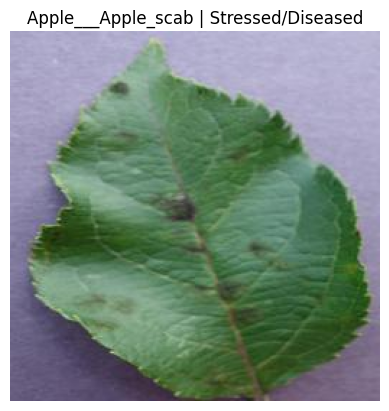

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = df_plantvillage.iloc[0]["image_path"]
sample_label = df_plantvillage.iloc[0]["binary_label"]
sample_class = df_plantvillage.iloc[0]["class_name"]

img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"{sample_class} | {sample_label}")
plt.show()

In [23]:
summary_path = "results/plantvillage_summary.csv"

binary_summary.to_csv(summary_path, index=False)

print("Summary saved at:", summary_path)
print(binary_summary)

Summary saved at: results/plantvillage_summary.csv
        binary_label  image_count
0            Healthy        15084
1  Stressed/Diseased        39221


In [24]:
import urllib.request
import zipfile
import os

url = "https://github.com/pratikkayal/PlantDoc-Dataset/archive/refs/heads/master.zip"
zip_path = "data/PlantDoc/PlantDoc-Dataset-master.zip"
extract_dir = "data/PlantDoc"

urllib.request.urlretrieve(url, zip_path)

print("Downloaded:", zip_path)

Downloaded: data/PlantDoc/PlantDoc-Dataset-master.zip


In [25]:
import zipfile
import os

zip_path = "data/PlantDoc/PlantDoc-Dataset-master.zip"
extract_dir = "data/PlantDoc"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction finished.")
print(os.listdir(extract_dir))

Extraction finished.
['PlantDoc-Dataset-master', 'PlantDoc-Dataset-master.zip']


In [26]:
import os

plantdoc_root = "data/PlantDoc/PlantDoc-Dataset-master"

print("Folders inside PlantDoc:")
print(os.listdir(plantdoc_root))

Folders inside PlantDoc:
['LICENSE.txt', 'PlantDoc_Examples.png', 'README.md', 'test', 'train']


In [27]:
import os

plantdoc_train_path = "data/PlantDoc/PlantDoc-Dataset-master/train"
plantdoc_test_path = "data/PlantDoc/PlantDoc-Dataset-master/test"

train_classes = sorted(os.listdir(plantdoc_train_path))
test_classes = sorted(os.listdir(plantdoc_test_path))

print("Number of train classes:", len(train_classes))
print("Number of test classes:", len(test_classes))

print("\nFirst 10 train classes:")
for c in train_classes[:10]:
    print(c)

Number of train classes: 28
Number of test classes: 27

First 10 train classes:
Apple Scab Leaf
Apple leaf
Apple rust leaf
Bell_pepper leaf
Bell_pepper leaf spot
Blueberry leaf
Cherry leaf
Corn Gray leaf spot
Corn leaf blight
Corn rust leaf


In [28]:
import os
import pandas as pd

plantdoc_train_path = "data/PlantDoc/PlantDoc-Dataset-master/train"
plantdoc_test_path = "data/PlantDoc/PlantDoc-Dataset-master/test"

rows = []

for split_name, split_path in [("train", plantdoc_train_path), ("test", plantdoc_test_path)]:
    for class_name in sorted(os.listdir(split_path)):
        class_dir = os.path.join(split_path, class_name)
        
        if os.path.isdir(class_dir):
            image_count = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            
            rows.append({
                "split": split_name,
                "class_name": class_name,
                "image_count": image_count
            })

df_plantdoc_counts = pd.DataFrame(rows)

print(df_plantdoc_counts)
print("Total images:", df_plantdoc_counts["image_count"].sum())

    split                            class_name  image_count
0   train                       Apple Scab Leaf           83
1   train                            Apple leaf           82
2   train                       Apple rust leaf           78
3   train                      Bell_pepper leaf           53
4   train                 Bell_pepper leaf spot           62
5   train                        Blueberry leaf          104
6   train                           Cherry leaf           47
7   train                   Corn Gray leaf spot           64
8   train                      Corn leaf blight          179
9   train                        Corn rust leaf          106
10  train                            Peach leaf          102
11  train              Potato leaf early blight          108
12  train               Potato leaf late blight           97
13  train                        Raspberry leaf          112
14  train                         Soyabean leaf           57
15  train            Squ

In [29]:
import os
import pandas as pd

plantdoc_train_path = "data/PlantDoc/PlantDoc-Dataset-master/train"
plantdoc_test_path = "data/PlantDoc/PlantDoc-Dataset-master/test"

rows = []

for split_name, split_path in [("train", plantdoc_train_path), ("test", plantdoc_test_path)]:
    for class_name in sorted(os.listdir(split_path)):
        class_dir = os.path.join(split_path, class_name)

        if os.path.isdir(class_dir):
            class_lower = class_name.lower()

            if class_lower.endswith("leaf") and not any(word in class_lower for word in [
                "scab", "rust", "spot", "blight", "mildew", "mosaic", "yellow", "mold", "mites", "black rot"
            ]):
                binary_label = "Healthy"
            else:
                binary_label = "Stressed/Diseased"

            for image_name in os.listdir(class_dir):
                if image_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    image_path = os.path.join(class_dir, image_name)

                    rows.append({
                        "split": split_name,
                        "image_path": image_path,
                        "class_name": class_name,
                        "binary_label": binary_label
                    })

df_plantdoc = pd.DataFrame(rows)

print(df_plantdoc.head())
print("Total images:", len(df_plantdoc))
print(df_plantdoc["binary_label"].value_counts())

   split                                         image_path       class_name  \
0  train  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...  Apple Scab Leaf   
1  train  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...  Apple Scab Leaf   
2  train  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...  Apple Scab Leaf   
3  train  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...  Apple Scab Leaf   
4  train  data/PlantDoc/PlantDoc-Dataset-master/train\Ap...  Apple Scab Leaf   

        binary_label  
0  Stressed/Diseased  
1  Stressed/Diseased  
2  Stressed/Diseased  
3  Stressed/Diseased  
4  Stressed/Diseased  
Total images: 2572
binary_label
Stressed/Diseased    1725
Healthy               847
Name: count, dtype: int64


In [30]:
output_path = "data/PlantDoc/plantdoc_binary_metadata.csv"

df_plantdoc.to_csv(output_path, index=False)

print("CSV saved at:", output_path)
print("Number of rows:", len(df_plantdoc))

CSV saved at: data/PlantDoc/plantdoc_binary_metadata.csv
Number of rows: 2572


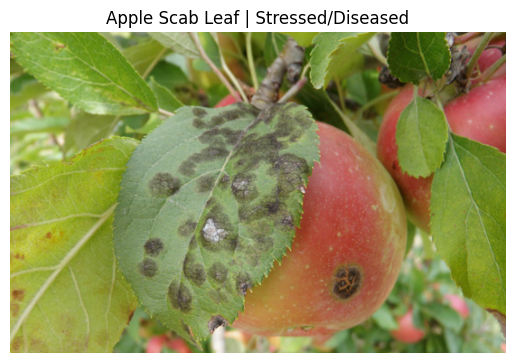

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = df_plantdoc.iloc[0]["image_path"]
sample_label = df_plantdoc.iloc[0]["binary_label"]
sample_class = df_plantdoc.iloc[0]["class_name"]

img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"{sample_class} | {sample_label}")
plt.show()

In [32]:
plantdoc_summary = df_plantdoc["binary_label"].value_counts().reset_index()
plantdoc_summary.columns = ["binary_label", "image_count"]

summary_path = "results/plantdoc_summary.csv"

plantdoc_summary.to_csv(summary_path, index=False)

print("Summary saved at:", summary_path)
print(plantdoc_summary)

Summary saved at: results/plantdoc_summary.csv
        binary_label  image_count
0  Stressed/Diseased         1725
1            Healthy          847


In [33]:
!pip install kaggle


   ----- ---------------------------------- 1/7 [python-slugify]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------------- ---------------------- 3/7 [mdit-py-plugins]
   ----------------- ---------------------- 3/7 [mdit-py-plugins]
   ----------------- ---------------------- 3/7 [mdit-py-plugins]
   ----------------- -------

In [34]:
kaggle.json

NameError: name 'kaggle' is not defined

In [35]:
kaggle.json

NameError: name 'kaggle' is not defined

In [36]:
import os
import shutil

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "kaggle.json")
kaggle_dir = os.path.join(os.path.expanduser("~"), ".kaggle")
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")

os.makedirs(kaggle_dir, exist_ok=True)

shutil.copy(downloads_path, kaggle_json_path)

print("kaggle.json copied to:")
print(kaggle_json_path)

kaggle.json copied to:
C:\Users\user\.kaggle\kaggle.json


In [37]:
!kaggle competitions list -s plant-pathology

ref                                                             deadline             category      reward  teamCount  userHasEntered  
--------------------------------------------------------------  -------------------  ---------  ---------  ---------  --------------  
https://www.kaggle.com/competitions/plant-pathology-2020-fgvc7  2020-05-26 23:59:00  Research   Knowledge       1317           False  
https://www.kaggle.com/competitions/plant-pathology-2021-fgvc8  2021-05-26 23:59:00  Research   Knowledge        625           False  
https://www.kaggle.com/competitions/plant-pathology             2021-05-05 23:59:00  Community      Kudos          4           False  


In [38]:
!kaggle competitions download -c plant-pathology-2020-fgvc7 -p data/PlantPathology2020

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [39]:
!kaggle competitions download -c plant-pathology-2020-fgvc7 -p data/PlantPathology2020


  0%|          | 0.00/779M [00:00<?, ?B/s]
  0%|          | 1.00M/779M [00:00<07:56, 1.71MB/s]
  0%|          | 2.00M/779M [00:00<04:05, 3.32MB/s]
  1%|          | 5.00M/779M [00:00<01:30, 8.99MB/s]
  1%|1         | 8.00M/779M [00:00<01:00, 13.3MB/s]
  1%|1         | 10.0M/779M [00:01<00:55, 14.6MB/s]
  2%|1         | 12.0M/779M [00:01<01:13, 11.0MB/s]
  2%|1         | 14.0M/779M [00:02<02:13, 6.00MB/s]
  2%|2         | 19.0M/779M [00:02<01:11, 11.2MB/s]
  3%|2         | 22.0M/779M [00:02<01:05, 12.2MB/s]
  3%|3         | 24.0M/779M [00:02<01:04, 12.3MB/s]
  3%|3         | 26.0M/779M [00:02<01:04, 12.3MB/s]
  4%|3         | 29.0M/779M [00:02<00:52, 15.1MB/s]
  4%|4         | 32.0M/779M [00:02<00:45, 17.2MB/s]
  4%|4         | 34.0M/779M [00:03<00:49, 15.8MB/s]
  5%|4         | 38.0M/779M [00:03<00:36, 21.1MB/s]
  5%|5         | 41.0M/779M [00:03<00:35, 21.6MB/s]
  6%|5         | 44.0M/779M [00:03<00:34, 22.3MB/s]
  6%|6         | 47.0M/779M [00:03<00:33, 22.8MB/s]
  6%|6         | 50.

In [40]:
import os

folder = "data/PlantPathology2020"

print(os.listdir(folder))

['plant-pathology-2020-fgvc7.zip']


In [41]:
import zipfile
import os

zip_path = "data/PlantPathology2020/plant-pathology-2020-fgvc7.zip"
extract_dir = "data/PlantPathology2020"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction finished.")
print(os.listdir(extract_dir))

Extraction finished.
['images', 'plant-pathology-2020-fgvc7.zip', 'sample_submission.csv', 'test.csv', 'train.csv']


In [42]:
import pandas as pd

pp2020_train_csv = "data/PlantPathology2020/train.csv"

df_pp2020_train = pd.read_csv(pp2020_train_csv)

print(df_pp2020_train.head())
print("Number of rows:", len(df_pp2020_train))

  image_id  healthy  multiple_diseases  rust  scab
0  Train_0        0                  0     0     1
1  Train_1        0                  1     0     0
2  Train_2        1                  0     0     0
3  Train_3        0                  0     1     0
4  Train_4        1                  0     0     0
Number of rows: 1821


In [43]:
import os
import pandas as pd

images_dir = "data/PlantPathology2020/images"

rows = []

for _, row in df_pp2020_train.iterrows():
    image_id = row["image_id"]
    image_path = os.path.join(images_dir, image_id + ".jpg")
    
    if row["healthy"] == 1:
        binary_label = "Healthy"
        class_name = "healthy"
    else:
        binary_label = "Stressed/Diseased"
        
        if row["rust"] == 1:
            class_name = "rust"
        elif row["scab"] == 1:
            class_name = "scab"
        elif row["multiple_diseases"] == 1:
            class_name = "multiple_diseases"
        else:
            class_name = "unknown"
    
    rows.append({
        "image_path": image_path,
        "image_id": image_id,
        "class_name": class_name,
        "binary_label": binary_label
    })

df_pp2020 = pd.DataFrame(rows)

print(df_pp2020.head())
print("Total images:", len(df_pp2020))
print(df_pp2020["binary_label"].value_counts())

                                   image_path image_id         class_name  \
0  data/PlantPathology2020/images\Train_0.jpg  Train_0               scab   
1  data/PlantPathology2020/images\Train_1.jpg  Train_1  multiple_diseases   
2  data/PlantPathology2020/images\Train_2.jpg  Train_2            healthy   
3  data/PlantPathology2020/images\Train_3.jpg  Train_3               rust   
4  data/PlantPathology2020/images\Train_4.jpg  Train_4            healthy   

        binary_label  
0  Stressed/Diseased  
1  Stressed/Diseased  
2            Healthy  
3  Stressed/Diseased  
4            Healthy  
Total images: 1821
binary_label
Stressed/Diseased    1305
Healthy               516
Name: count, dtype: int64


In [44]:
output_path = "data/PlantPathology2020/plantpathology2020_binary_metadata.csv"

df_pp2020.to_csv(output_path, index=False)

print("CSV saved at:", output_path)
print("Number of rows:", len(df_pp2020))

CSV saved at: data/PlantPathology2020/plantpathology2020_binary_metadata.csv
Number of rows: 1821


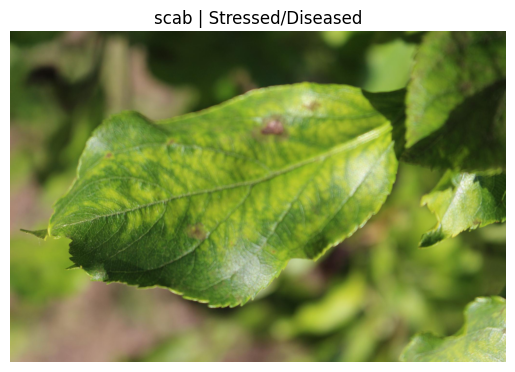

In [45]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = df_pp2020.iloc[0]["image_path"]
sample_label = df_pp2020.iloc[0]["binary_label"]
sample_class = df_pp2020.iloc[0]["class_name"]

img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")
plt.title(f"{sample_class} | {sample_label}")
plt.show()

In [46]:
pp2020_summary = df_pp2020["binary_label"].value_counts().reset_index()
pp2020_summary.columns = ["binary_label", "image_count"]

summary_path = "results/plantpathology2020_summary.csv"

pp2020_summary.to_csv(summary_path, index=False)

print("Summary saved at:", summary_path)
print(pp2020_summary)

Summary saved at: results/plantpathology2020_summary.csv
        binary_label  image_count
0  Stressed/Diseased         1305
1            Healthy          516


In [47]:
import pandas as pd

global_summary = pd.concat([
    binary_summary.assign(dataset="PlantVillage"),
    plantdoc_summary.assign(dataset="PlantDoc"),
    pp2020_summary.assign(dataset="PlantPathology2020")
], ignore_index=True)

global_summary = global_summary[["dataset", "binary_label", "image_count"]]

output_path = "results/global_dataset_summary.csv"
global_summary.to_csv(output_path, index=False)

print("Global summary saved at:", output_path)
print(global_summary)

Global summary saved at: results/global_dataset_summary.csv
              dataset       binary_label  image_count
0        PlantVillage            Healthy        15084
1        PlantVillage  Stressed/Diseased        39221
2            PlantDoc  Stressed/Diseased         1725
3            PlantDoc            Healthy          847
4  PlantPathology2020  Stressed/Diseased         1305
5  PlantPathology2020            Healthy          516


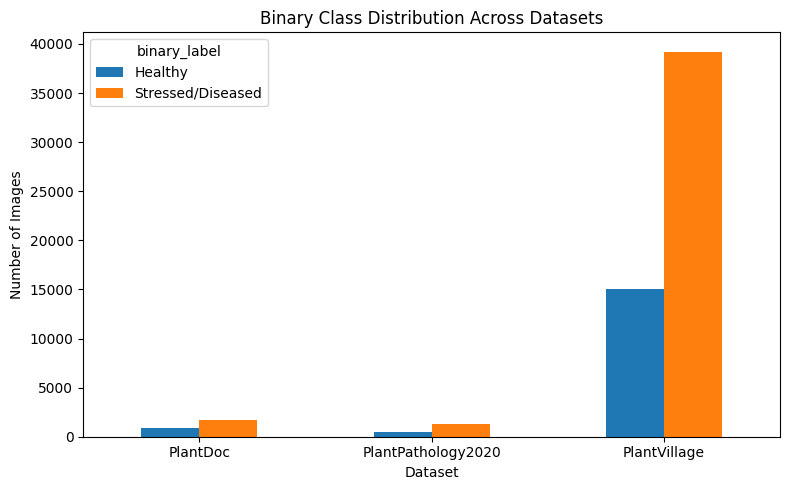

Figure saved at: results/global_dataset_summary.png


In [48]:
import matplotlib.pyplot as plt

pivot_summary = global_summary.pivot(
    index="dataset",
    columns="binary_label",
    values="image_count"
)

pivot_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Binary Class Distribution Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = "results/global_dataset_summary.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print("Figure saved at:", figure_path)

In [49]:
import pandas as pd

metadata_files = pd.DataFrame([
    {
        "dataset": "PlantVillage",
        "metadata_csv": "data/PlantVillage/plantvillage_binary_metadata.csv"
    },
    {
        "dataset": "PlantDoc",
        "metadata_csv": "data/PlantDoc/plantdoc_binary_metadata.csv"
    },
    {
        "dataset": "PlantPathology2020",
        "metadata_csv": "data/PlantPathology2020/plantpathology2020_binary_metadata.csv"
    }
])

output_path = "results/metadata_files.csv"
metadata_files.to_csv(output_path, index=False)

print("Metadata file list saved at:", output_path)
print(metadata_files)

Metadata file list saved at: results/metadata_files.csv
              dataset                                       metadata_csv
0        PlantVillage  data/PlantVillage/plantvillage_binary_metadata...
1            PlantDoc         data/PlantDoc/plantdoc_binary_metadata.csv
2  PlantPathology2020  data/PlantPathology2020/plantpathology2020_bin...
